<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 52%, #2f7d73 100%);
    padding: 38px 34px 30px 34px;
    border-radius: 14px;
    margin: 8px 0 22px 0;
    box-shadow: 0 10px 28px rgba(16, 42, 67, 0.28);
    border: 1px solid rgba(255,255,255,0.16);
    text-align: center;
">
    <p style="color: rgba(255,255,255,0.72); margin: 0 0 10px 0; font-size: 12px; letter-spacing: 4px; text-transform: uppercase;">PHY-3202 · Laboratoire 02</p>
    <h1 style="color: white; margin: 0; font-size: 34px; font-weight: 400; letter-spacing: 1px;">Dispatch et transitions de charge</h1>
    <div style="width: 72px; height: 3px; background: #e7a23b; margin: 18px auto 14px auto; border-radius: 3px;"></div>
    <p style="color: rgba(255,255,255,0.92); margin: 0; font-size: 17px;">Détection entropique des pannes en cascade</p>
</div>

<div style="
    background: var(--vscode-textBlockQuote-background, rgba(31,78,95,0.10));
    border-left: 6px solid #1f4e5f;
    border-radius: 9px;
    padding: 16px 20px;
    margin: 0 0 18px 0;
">
<strong>Auteur :</strong> Alex Baker &nbsp; · &nbsp; <strong>Superviseur :</strong> Patrick Desrosiers
</div>

## Fil directeur

Le carnet 01 couvrait les outils d'analyse. Celui-ci suit le modèle de réseau :
comment la production est répartie sous contraintes, puis comment cette répartition
évolue lorsque la demande augmente.

<div style="
    background: var(--vscode-editor-inactiveSelectionBackground, rgba(231,162,59,0.12));
    border: 1px solid rgba(231,162,59,0.55);
    border-radius: 9px;
    padding: 16px 20px;
    margin: 18px 0 6px 0;
    color: var(--vscode-editor-foreground, inherit);
">
<strong style="color: #1f4e5f;">Au programme</strong>
<ol style="margin: 10px 0 0 20px; padding: 0; line-height: 1.7;">
<li>Le dispatch, avec un cas vérifiable à la main</li>
<li>Un réseau chargé, ligne par ligne</li>
<li>Les deux transitions du modèle</li>
<li>Ce que voit l'entropie de répartition</li>
<li>Une avarie de ligne, et pourquoi l'arbre a ses limites</li>
</ol>
</div>

<div style="text-align: center; color: var(--vscode-descriptionForeground, #6b7c85); font-size: 12px; margin-top: 18px;">
<strong>Question directrice :</strong> que révèle la distribution des flux avant même qu'une cascade ne commence ?
</div>

In [1]:
import numpy as np

from cascade_entropy import figures
from cascade_entropy.dispatch import demande_uniforme, resoudre
from cascade_entropy.entropie import entropie_repartition, nombre_effectif
from cascade_entropy.reseau import (
    Reseau,
    arbre,
    limites_par_niveau,
    matrice_de_flux,
)

figures.appliquer_style()

GRAINE = 20260915
P_C = 2623.9            # capacité totale de production, valeur publiée
CIBLE_SECONDE = 1.45    # niveau de charge visé pour la saturation des lignes

rng = np.random.default_rng(GRAINE)

<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 01 · Optimisation</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Le dispatch</h2>
</div>

Étant donné une demande, le dispatch décide quel générateur produit combien et
quelle charge est servie. Le problème est linéaire :

$$\min \;\; \sum_i G_i - W \sum_j L_j$$

sous quatre contraintes — capacités de production, demande non dépassée,
équilibre global, et limites de transport. Avec $W = 100$, servir la charge
rapporte cent fois plus que produire ne coûte : le solveur sert donc le maximum
possible, et coupe le moins possible quand il ne peut pas tout servir.

<div style="background: #f8f4ea; color: #1f2933; border-left: 4px solid #e7a23b; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Repère de lecture.</strong> Avant d'appliquer le modèle à 46 nœuds, on commence par un cas que l'on peut vérifier de tête.
</div>

In [2]:
chaine = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([10.0, 10.0]),
    reference=0,
)

solution = resoudre(chaine, demande=np.array([1.0, 1.0]),
                    puissance_max=np.array([10.0]))

print("Chaîne 0—1—2, générateur en 0, deux charges d'une unité")
print(f"  production      : {solution.production}")
print(f"  charge servie   : {solution.charge_servie}")
print(f"  flux            : {solution.flux}   (attendu [2, 1])")
print(f"  délestage       : {solution.delestage_total}")

Chaîne 0—1—2, générateur en 0, deux charges d'une unité
  production      : [2.]
  charge servie   : [1. 1.]
  flux            : [2. 1.]   (attendu [2, 1])
  délestage       : 0.0


Le générateur produit 2, la première ligne porte les deux charges, la seconde n'en porte qu'une. C'est le seul résultat physiquement possible, et le solveur le retrouve.

**Pourquoi on peut vérifier ce résultat « à la main ».** Dans une chaîne, il n'existe qu'un seul chemin entre le générateur et chaque charge — aucune boucle, aucun choix de routage possible. La charge en 2 ne peut recevoir sa puissance que par la ligne 1—2 : son flux vaut donc exactement 1. La charge en 1 est alimentée par la ligne 0—1, qui est aussi le seul passage vers tout ce qui est en aval : elle transporte donc la demande de la charge 1 plus tout ce qui continue vers la charge 2, soit $1 + 1 = 2$. Le générateur produit ce que la chaîne réclame au total. Aucune équation à résoudre — seulement suivre où l'énergie doit obligatoirement circuler.

C'est la règle générale documentée dans `reseau.py` : sur un arbre, le flux d'une ligne égale toujours la somme des injections du sous-arbre qu'elle alimente, indépendamment des réactances. Les réactances n'entreraient en jeu que s'il existait plusieurs chemins possibles entre lesquels répartir le courant — ce qui n'arrive jamais dans un arbre.

Maintenant, la même chose avec la ligne amont plafonnée à 1,5.

In [4]:
chaine_limitee = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([1.5, 10.0]),
    reference=0,
)

limitee = resoudre(chaine_limitee, demande=np.array([1.0, 1.0]),
                   puissance_max=np.array([10.0]))

print(f"  flux            : {limitee.flux}")
print(f"  charge servie   : {limitee.charge_servie}")
print(f"  délestage       : {limitee.delestage_total}   (attendu 0,5)")
print(f"  M_max           : {limitee.taux_maximal}")
print(f"  lignes saturées : {limitee.lignes_saturees}")

  flux            : [1.5 1. ]
  charge servie   : [0.5 1. ]
  délestage       : 0.5   (attendu 0,5)
  M_max           : 1.0
  lignes saturées : [0]


**Le point le plus important du module.** La ligne est à 1,5 sur une limite de
1,5, donc son taux de charge vaut exactement 1. Elle est **saturée**, pas en
dépassement — et elle ne le sera jamais, puisque la contrainte est dure dans le
problème d'optimisation.

C'est ce qui définit la surcharge dans le modèle de cascade : une ligne collée
contre sa limite. Le module `cascade` fera tomber ces lignes-là avec une
probabilité $p_1$, jamais des lignes en dépassement, qui n'existent pas.

<div style="
    background: linear-gradient(135deg, #2f7d73 0%, #4f9d8b 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(47,125,115,0.20);
">
    <p style="color: #e6f5f0; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 02 · Réseau</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Un réseau chargé</h2>
</div>

Passons au réseau à 46 nœuds. Les capacités de lignes décroissent avec la
profondeur de l'arbre, puisqu'une ligne proche de la racine doit écouler la
puissance de tout son sous-arbre.

<div style="background: #eef7f4; color: #1f2933; border-left: 4px solid #2f7d73; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Idée physique.</strong> Plus une ligne est proche de la racine, plus elle agrège de puissance et plus sa capacité doit être importante.
</div>

In [10]:
reseau = arbre(4)
A = matrice_de_flux(reseau)
p_max = np.full(reseau.generateurs.size, P_C / reseau.generateurs.size)

# L'échelle des capacités est le seul paramètre libre : elle est fixée pour que
# la saturation apparaisse au niveau de charge rapporté dans la littérature.
base = limites_par_niveau(reseau)
facteur = resoudre(reseau, demande_uniforme(reseau, CIBLE_SECONDE * P_C),
                   limites=base, puissance_max=p_max, A=A).taux_maximal
limites = base * facteur

print(f"{reseau.n_noeuds} nœuds, {reseau.n_lignes} lignes, "
      f"{reseau.generateurs.size} générateurs")
print(f"capacités par niveau : {np.unique(limites).round(1)}")
print(f"facteur d'échelle appliqué aux valeurs publiées : {facteur:.4f}")

46 nœuds, 45 lignes, 12 générateurs
capacités par niveau : [111.9 231.3 470.  947.4]
facteur d'échelle appliqué aux valeurs publiées : 0.0607


Deux constantes interviennent, définies tout en haut du carnet :

- `P_C = 2623.9` — la capacité totale de production du réseau à 46 nœuds,
  valeur publiée par Carreras et al. (2002), Tableau I.
- `CIBLE_SECONDE = 1,45` — le rapport $P_D/P_C$ auquel Carreras rapportent
  l'apparition de la saturation des lignes (la « seconde transition »).

`base = limites_par_niveau(reseau)` reprend elle aussi les capacités publiées
telles quelles. Mais utilisées brutes, elles sont bien trop grandes par rapport
à `P_C` — à cette échelle, aucune ligne ne saturerait jamais, quel que soit le
niveau de charge. Il faut donc les ramener à la bonne échelle.

**Comment `facteur` est calculé.** On résout le dispatch à la demande précise
`CIBLE_SECONDE × P_C`, avec les capacités brutes (`base`). À cette échelle,
aucune ligne ne contraint la solution : le résultat est simplement la
répartition naturelle des flux à ce niveau de charge. `facteur` est le taux de
charge maximal (`M_max`) obtenu dans cette solution non contrainte — la ligne
la plus sollicitée n'utilise alors qu'une petite fraction de sa capacité
publiée.

En multipliant ensuite toutes les capacités par ce même `facteur`
(`limites = base * facteur`), les proportions entre niveaux ne changent pas —
seulement l'échelle. Mais l'effet est immédiat : la ligne qui utilisait cette
petite fraction de la capacité brute se retrouve exactement à 100 % de la
capacité rétrécie. La saturation apparaît donc, par construction, pile à
$P_D/P_C = 1,45$.

<div style="background: #eef7f4; color: #1f2933; border-left: 4px solid #2f7d73; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>À ne pas confondre avec un résultat du modèle.</strong> La position
exacte de la seconde transition est calibrée, pas retrouvée — c'est le seul
paramètre libre de toute la procédure. Ce qui, en revanche, n'est pas calibré :
la première transition tombe à <em>P_D/P_C = 1<em> sans aucun réglage (cellules
suivantes), la fraction délestée au-delà suit exactement <em>(r-1)/r<em>, et le
<em>mécanisme</em> de la seconde transition — pourquoi <em>M_{max}<em> continue de
monter alors que la puissance totale servie reste fixe — émerge du modèle sans
avoir été programmé.
</div>

délestage   : 0.0
M_max       : 0.657
taux moyen  : 0.455


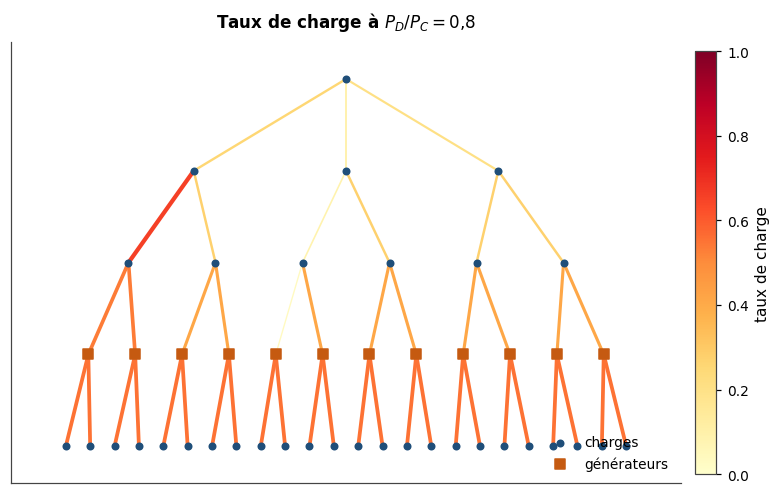

In [11]:
charge_moderee = resoudre(reseau, demande_uniforme(reseau, 0.8 * P_C),
                          limites=limites, puissance_max=p_max, A=A)

figures.reseau_en_arbre(reseau, taux=charge_moderee.taux_de_charge,
                        titre="Taux de charge à $P_D/P_C = 0{,}8$");

print(f"délestage   : {charge_moderee.delestage_total:.1f}")
print(f"M_max       : {charge_moderee.taux_maximal:.3f}")
print(f"taux moyen  : {charge_moderee.taux_de_charge.mean():.3f}")

<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(36,75,99,0.20);
">
    <p style="color: #dceef4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 03 · Régimes critiques</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Les deux transitions</h2>
</div>

On augmente maintenant la demande à profil fixe, et on observe comment se succèdent
la saturation de la production puis celle du transport.

<div style="background: #edf5f8; color: #1f2933; border-left: 4px solid #347b91; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Question d'observation.</strong> La puissance totale servie peut-elle rester constante alors que la charge des lignes continue d'augmenter ?
</div>

In [12]:
RATIOS = np.linspace(0.2, 2.0, 55)

colonnes = {cle: [] for cle in
            ("servie", "delestage", "taux_max", "taux_moyen", "saturees", "lignes_eff")}

for ratio in RATIOS:
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    colonnes["servie"].append(s.charge_servie.sum() / P_C)
    colonnes["delestage"].append(s.delestage_total / (ratio * P_C))
    colonnes["taux_max"].append(s.taux_maximal)
    colonnes["taux_moyen"].append(s.taux_de_charge.mean())
    colonnes["saturees"].append(s.lignes_saturees.size)
    colonnes["lignes_eff"].append(nombre_effectif(s.flux))

balayage = {cle: np.array(v) for cle, v in colonnes.items()}
seuils = {"production": 1.0, "transport": CIBLE_SECONDE}

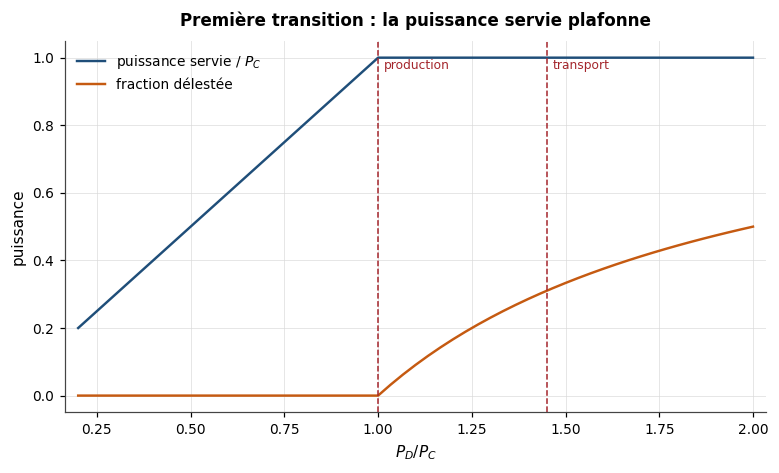

In [13]:
figures.transitions(
    RATIOS,
    {"puissance servie / $P_C$": balayage["servie"],
     "fraction délestée": balayage["delestage"]},
    seuils, ylabel="puissance",
    titre="Première transition : la puissance servie plafonne",
);

Le délestage démarre exactement à $P_D/P_C = 1$, et la puissance servie
plafonne définitivement. Aucun réglage n'intervient ici : c'est la conséquence
directe de la contrainte de capacité de production.

Au-delà, la fraction délestée vaut exactement $(r-1)/r$, ce qui se vérifie sur
les valeurs ci-dessous.

In [6]:
for ratio in (1.2, 1.5, 2.0):
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    mesure = s.delestage_total / (ratio * P_C)
    print(f"P_D/P_C = {ratio}  →  délesté {mesure:.4f}, attendu {(ratio-1)/ratio:.4f}")

P_D/P_C = 1.2  →  délesté 0.1667, attendu 0.1667
P_D/P_C = 1.5  →  délesté 0.3333, attendu 0.3333
P_D/P_C = 2.0  →  délesté 0.5000, attendu 0.5000


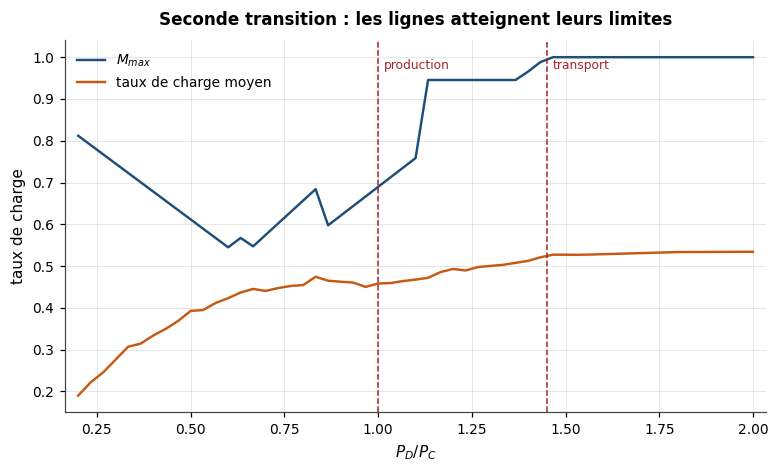

In [14]:
figures.transitions(
    RATIOS,
    {"$M_{max}$": balayage["taux_max"],
     "taux de charge moyen": balayage["taux_moyen"]},
    seuils, ylabel="taux de charge",
    titre="Seconde transition : les lignes atteignent leurs limites",
);

**Voici l'observation qui n'a pas été programmée.**

Au-delà de la première transition, la puissance totale servie ne bouge plus.
Elle est rigoureusement constante. Et pourtant $M_{\max}$ continue de monter,
jusqu'à atteindre 1.

Comment une puissance constante peut-elle charger davantage les lignes ? Parce
que le délestage n'est pas uniforme. Le solveur coupe là où c'est le moins
coûteux compte tenu des contraintes, donc la **répartition** de la puissance
entre les charges change même quand le **total** reste fixe. Les flux suivent
cette redistribution.

C'est exactement le mécanisme que Carreras invoque pour expliquer l'existence
d'une seconde transition. Il émerge ici du modèle, il n'y a pas été mis.

<div style="
    background: linear-gradient(135deg, #8b5e34 0%, #b47a3c 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f1c36b;
    box-shadow: 0 6px 18px rgba(139,94,52,0.20);
">
    <p style="color: #fff1d4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 04 · Observable</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Ce que voit l'entropie de répartition</h2>
</div>

L'observable retenue dans SO2 est l'entropie de la distribution des flux. Son
exponentielle donne le **nombre effectif de lignes** portant le réseau : si
quarante-cinq lignes se partagent la puissance également, la valeur est 45 ; si
une seule porte tout, elle est 1.

<div style="background: #fbf5ec; color: #1f2933; border-left: 4px solid #b47a3c; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Lecture informationnelle.</strong> L'entropie ne mesure pas seulement combien de puissance circule, mais comment elle se répartit entre les lignes.
</div>

à P_D/P_C = 0,2 : 22.9 lignes effectives
au maximum      : 44.9
à P_D/P_C = 2,0 : 25.9 lignes effectives


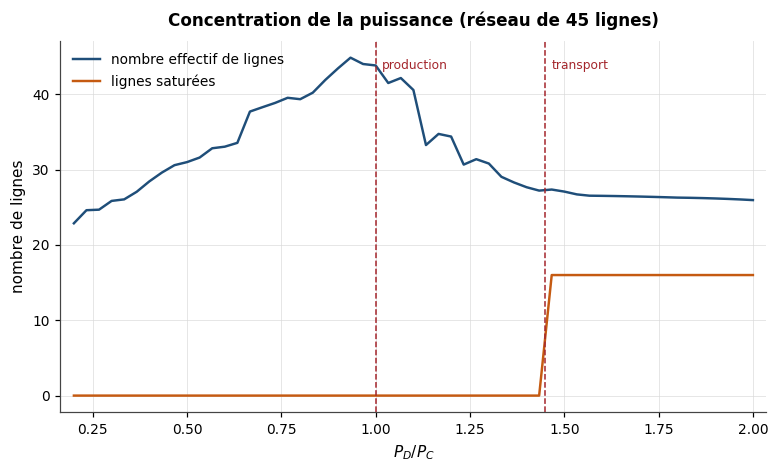

In [15]:
figures.transitions(
    RATIOS,
    {"nombre effectif de lignes": balayage["lignes_eff"],
     "lignes saturées": balayage["saturees"]},
    seuils, ylabel="nombre de lignes",
    titre=f"Concentration de la puissance (réseau de {reseau.n_lignes} lignes)",
);

print(f"à P_D/P_C = 0,2 : {balayage['lignes_eff'][0]:.1f} lignes effectives")
print(f"au maximum      : {balayage['lignes_eff'].max():.1f}")
print(f"à P_D/P_C = 2,0 : {balayage['lignes_eff'][-1]:.1f} lignes effectives")

La courbe monte jusqu'à frôler 45 juste avant la première transition — la
puissance y est répartie de façon presque parfaitement homogène — puis chute
nettement lorsque le réseau se charge. La puissance se concentre.

C'est la première fois que les deux fils du projet se touchent : une mesure
informationnelle, développée et validée sans aucune donnée électrique, répond
visiblement au niveau de stress du réseau.

**Attention à ne pas conclure trop vite.** Cette courbe ne démontre rien encore.
Il faudra vérifier qu'elle dit quelque chose que $M_{\max}$ ou la charge moyenne
ne disent pas déjà. C'est précisément l'objet du sous-objectif SO3.

$P_D/P_C = 0.5$ : moyenne 0.393, max 0.612, entropie 0.988
$P_D/P_C = 1.0$ : moyenne 0.458, max 0.690, entropie 0.950
$P_D/P_C = 1.5$ : moyenne 0.527, max 1.000, entropie 0.875


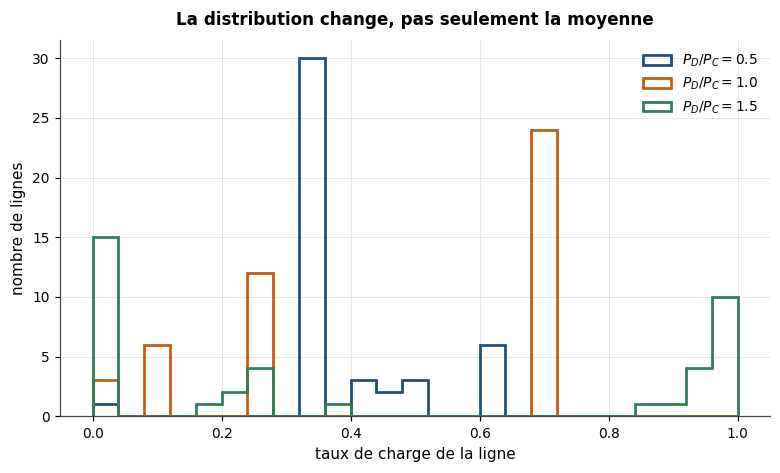

In [16]:
cas = {}
for ratio in (0.5, 1.0, 1.5):
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    cas[f"$P_D/P_C = {ratio}$"] = s.taux_de_charge

figures.distributions_taux(cas, titre="La distribution change, pas seulement la moyenne");

for nom, taux in cas.items():
    print(f"{nom} : moyenne {taux.mean():.3f}, max {taux.max():.3f}, "
          f"entropie {entropie_repartition(taux, normaliser=True):.3f}")

Deux réseaux peuvent avoir un taux de charge moyen voisin et des distributions
très différentes. C'est cette différence que l'entropie capte et que la moyenne
manque.

<div style="
    background: linear-gradient(135deg, #6b3f4f 0%, #9a5361 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f0b56b;
    box-shadow: 0 6px 18px rgba(107,63,79,0.20);
">
    <p style="color: #fbe7df; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 05 · Résilience</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Une avarie de ligne</h2>
</div>

Aperçu du module suivant. Une ligne tombe : sa capacité passe à zéro, et on
relance le dispatch.

<div style="background: #fbf0f1; color: #1f2933; border-left: 4px solid #9a5361; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Point de vigilance.</strong> Dans un arbre, une panne isole un sous-arbre au lieu de redistribuer les flux comme le ferait un réseau maillé.
</div>

ligne perdue : 3, reliant les nœuds [1 4]
délestage    : 0.0  →  0.0
M_max        : 0.657  →  0.569
lignes eff.  : 39.3  →  39.7


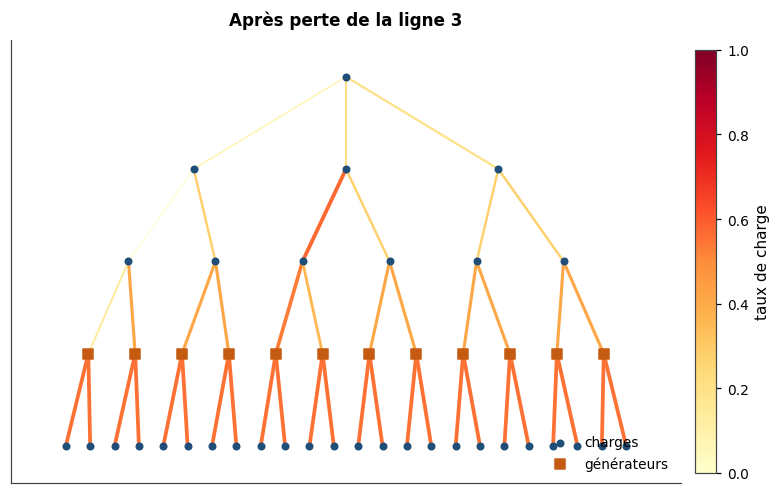

In [17]:
avant = resoudre(reseau, demande_uniforme(reseau, 0.8 * P_C),
                 limites=limites, puissance_max=p_max, A=A)

# On fait tomber la ligne la plus chargée. Une ligne en panne n'est pas retirée du
# réseau : sa réactance est rendue très grande et sa capacité très petite, ce qui
# évite de rendre la matrice singulière.
ligne_perdue = int(np.argmax(avant.taux_de_charge))

reseau_apres = Reseau(
    n_noeuds=reseau.n_noeuds, lignes=reseau.lignes,
    reactances=reseau.reactances.copy(), generateurs=reseau.generateurs,
    charges=reseau.charges, niveaux=reseau.niveaux, reference=reseau.reference,
)
reseau_apres.reactances[ligne_perdue] *= 1e6
limites_apres = limites.copy()
limites_apres[ligne_perdue] *= 1e-6

apres = resoudre(reseau_apres, demande_uniforme(reseau, 0.8 * P_C),
                 limites=limites_apres, puissance_max=p_max)

# La ligne hors service est exclue des statistiques : son taux de charge est le
# rapport de deux quantités quasi nulles et n'a aucun sens physique.
en_service = np.ones(reseau.n_lignes, dtype=bool)
en_service[ligne_perdue] = False

figures.reseau_en_arbre(reseau, taux=np.where(en_service, apres.taux_de_charge, 0.0),
                        titre=f"Après perte de la ligne {ligne_perdue}");

print(f"ligne perdue : {ligne_perdue}, reliant les nœuds {reseau.lignes[ligne_perdue]}")
print(f"délestage    : {avant.delestage_total:.1f}  →  {apres.delestage_total:.1f}")
print(f"M_max        : {avant.taux_maximal:.3f}  →  "
      f"{apres.taux_de_charge[en_service].max():.3f}")
print(f"lignes eff.  : {nombre_effectif(avant.flux):.1f}  →  "
      f"{nombre_effectif(apres.flux[en_service]):.1f}")

**Un piège découvert en écrivant ce carnet.** Le taux de charge de la ligne
morte vaut environ 1 : son flux est quasi nul, sa capacité aussi, et le rapport
de deux quantités quasi nulles ne veut rien dire. Si on l'incluait dans
$M_{\max}$, une ligne en panne apparaîtrait comme saturée en permanence et
serait retenue pour tomber à nouveau à chaque itération de la cascade.

Les lignes hors service doivent donc être suivies explicitement et exclues des
statistiques. C'est une contrainte de conception pour le module `cascade`.

**Et voici une limite du réseau en arbre, qu'il vaut mieux connaître d'avance.**

Dans un arbre, le chemin entre deux nœuds est unique. Perdre une ligne ne
redistribue donc rien : ça isole purement et simplement le sous-arbre situé en
aval, dont toute la charge doit être coupée.

Or la redistribution après avarie est précisément le mécanisme de propagation
d'une cascade dans un réseau maillé. Une cascade dans un arbre n'est donc pas
tout à fait le même phénomène que dans un réseau réel.

Carreras utilise quand même l'arbre, et prend le réseau IEEE 118-bus comme cas
maillé plus réaliste. Ça vaut une phrase dans le rapport d'étape, et ça figure
déjà dans la délimitation du plan de travail comme extension possible.

<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 100%);
    padding: 22px 26px;
    border-radius: 10px;
    margin: 34px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(16,42,67,0.22);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Bilan · Reproductibilité</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Où en est le projet</h2>
</div>

<div style="background: #f3f7f6; color: #1f2933; border: 1px solid #c9ddda; border-radius: 9px; padding: 16px 20px;">
<p><strong>En place et validé</strong> — les deux modules du fil B, et les deux premiers du fil A. 105 tests, environ vingt-cinq secondes.</p>
<p><strong>Reproduit</strong> — la première transition tombe exactement à la capacité de production, la fraction délestée suit exactement <em>(r - 1) / r</em>, et le mécanisme de la seconde transition émerge du modèle sans avoir été programmé.</p>
<p><strong>Calibré, et signalé comme tel</strong> — l'échelle des capacités de lignes est fixée pour que la saturation apparaisse au niveau rapporté dans la littérature. Ce n'est pas une prédiction du modèle.</p>
<p style="margin-bottom: 0;"><strong>Prochains modules</strong> — <code style="color: #1f4e5f; background: #dcefeb; padding: 1px 4px; border-radius: 3px;">cascade</code>, qui fera tomber les lignes saturées avec une probabilité <em>p₁</em> et relancera le dispatch en boucle, puis <code style="color: #1f4e5f; background: #dcefeb; padding: 1px 4px; border-radius: 3px;">evolution</code>, qui produira enfin les séries temporelles.</p>
</div>

<div style="text-align: center; color: var(--vscode-descriptionForeground, #6b7c85); font-size: 12px; margin-top: 16px;">
<strong>Du dispatch à l'entropie :</strong> la structure du réseau devient une observable.
</div>